29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
422/422 - 10s - 24ms/step - accuracy: 0.8014 - loss: 0.5529 - val_accuracy: 0.8430 - val_loss: 0.4176
Epoch 2/20
422/422 - 7s - 16ms/step - accuracy: 0.8559 - loss: 0.3959 - val_accuracy: 0.8598 - val_loss: 0.3830
Epoch 3/20
422/422 - 11s - 26ms/step - accuracy: 0.8682 - loss: 0.3576 - val_accuracy: 0.8798 - val_loss: 0.3287
Epoch 4/20
422/422 - 9s - 21ms/step - accuracy: 0.8754 - loss: 0.3365 - val_accuracy: 0.8793 - val_loss: 0.3415
Epoch 5/20
422/422 - 7s - 16ms/step - accuracy: 0.8792 - loss: 0.3226 - val_accuracy: 0.8822 - val_loss: 0.3198
Epoch 6/20
422/422 - 8s - 18ms/step - accuracy: 0.8858 - loss: 0.3068 - val_accuracy: 0.8773 - val_loss: 0.3446
Epoch 7/20
422/422 - 10s - 24ms/step - accuracy: 0.8899 - loss: 0.2955 - val_accuracy: 0.8815 - val_loss: 0.3303
Epoch 8/20
422/422 - 7s -

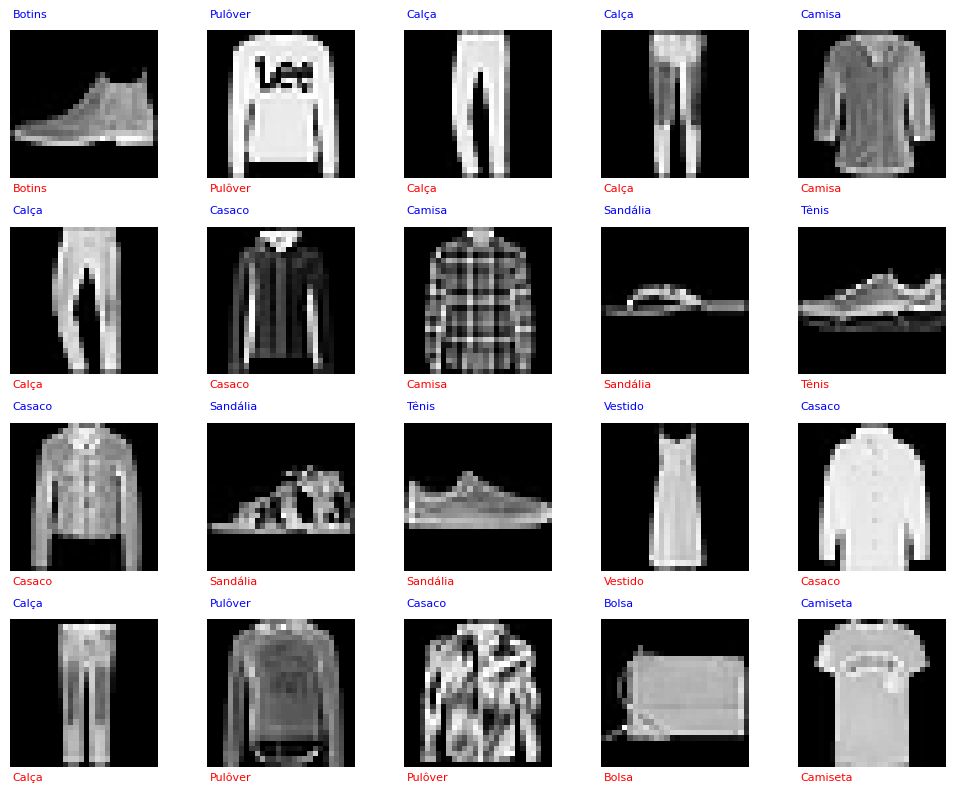

In [1]:
# fashion_mlp.py
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import matplotlib.pyplot as plt
import tensorflow.keras as keras
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

# ------------------------------------------------------------
# Categorias
# ------------------------------------------------------------
categories = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

categorias = [
    "Camiseta", "Calça", "Pulôver", "Vestido", "Casaco",
    "Sandália", "Camisa", "Tênis", "Bolsa", "Botins"
]

# ------------------------------------------------------------
# 1) Carrega Fashion-MNIST
# ------------------------------------------------------------
(AX, AY), (QX, QY) = fashion_mnist.load_data()

# Guarda cópias das imagens originais para exibição posterior
QX_img = QX.copy()

# ------------------------------------------------------------
# 2) Pré-processamento
# ------------------------------------------------------------
# Converte para float32 e normaliza para [0,1]
AX = AX.astype("float32") / 255.0
QX = QX.astype("float32") / 255.0

# Achata 28x28 -> 784
AX = AX.reshape(-1, 28 * 28)
QX = QX.reshape(-1, 28 * 28)

# One-hot dos rótulos
nclasses = 10
AY2 = keras.utils.to_categorical(AY, nclasses)
QY2 = keras.utils.to_categorical(QY, nclasses)

# ------------------------------------------------------------
# 3) Modelo denso
# ------------------------------------------------------------
# Uma boa configuração inicial para Fashion-MNIST com MLP
model = Sequential([
    Input(shape=(784,)),
    Dense(512, activation="relu"),
    Dropout(0.2),
    Dense(256, activation="relu"),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ------------------------------------------------------------
# 4) Treinamento
# ------------------------------------------------------------
history = model.fit(
    AX, AY2,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    verbose=2
)

# Salva o modelo
model.save("fashion_mlp.keras")

# ------------------------------------------------------------
# 5) Avaliação
# ------------------------------------------------------------
score = model.evaluate(QX, QY2, verbose=False)

print("Test loss: %.4f" % score[0])
print("Test accuracy: %.2f %%" % (100 * score[1]))
print("Test error: %.2f %%" % (100 * (1 - score[1])))

# ------------------------------------------------------------
# 6) Predição
# ------------------------------------------------------------
QP2 = model.predict(QX, verbose=0)
QP = QP2.argmax(axis=-1)

print("\nPrimeiras 20 imagens de teste:")
for i in range(20):
    print(
        f"Imagem-teste {i:2d}: "
        f"verdadeiro = {categorias[QY[i]]} "
        f"({QY[i]}), "
        f"predição = {categorias[QP[i]]} "
        f"({QP[i]})"
    )

# ------------------------------------------------------------
# 7) Figura com as 20 primeiras imagens
# ------------------------------------------------------------
f = plt.figure(figsize=(10, 8))

for i in range(20):
    ax = f.add_subplot(4, 5, i + 1)
    ax.imshow(QX_img[i], cmap="gray")
    ax.axis("off")

    # classificação verdadeira em azul
    ax.text(
        0, -3,
        categorias[QY[i]],
        color="blue",
        fontsize=8
    )

    # classificação predita em vermelho
    ax.text(
        0, 30,
        categorias[QP[i]],
        color="red",
        fontsize=8
    )

plt.tight_layout()
plt.savefig("fashion_mnist_20_primeiras.png", dpi=150)
plt.show()